# Milestone 3 — Stage 3: entry–exit refractive transport

**M3 Stage 3**: full `propagate_entry_exit_transport` → exit-face `FaceOpticalState` → camera sampling.

Plan: [`plans/milestone_03/03_face_transport_plan.md`](../../plans/milestone_03/03_face_transport_plan.md). Prerequisites: `03_0_ray_sampling_basics.ipynb`, `03_1_snell_helper_testing.ipynb`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from gummybear.geometry import inspect_stl
from gummybear.optics import (
    OpticalMaterialConfig,
    PointLightConfig,
    SourceSamplingParams,
    make_source_ray_bundle,
    propagate_entry_exit_transport,
)
from gummybear.rays.camera import PinholeCameraConfig, make_pinhole_rays
from gummybear.rays.visibility import first_visible_hits
from gummybear_validation.helpers import print_face_state_summary
from gummybear_validation.plotting import (
    plot_face_state_camera_panel,
    plot_face_state_on_mesh_3d,
    sample_face_state_camera_images,
)


In [3]:
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]

# Match upstream Stage 3 evidence (distinct from Stage 2 point-light pose).
light = PointLightConfig(position=(-20.0, 10.0, 20.0), intensity=100.0)
sampling = SourceSamplingParams(mode="point_uniform", n_rays=10000)
source_rays = make_source_ray_bundle(light, mesh_bbox=mesh.bounds, sampling=sampling)
material = OpticalMaterialConfig(n_refractive=1.33)


In [4]:
exit_state = propagate_entry_exit_transport(mesh, source_rays, material)
print_face_state_summary(exit_state, label="exit face state")

print("source total weight:", float(source_rays.weights.sum()))
print("exit accumulated energy:", float(exit_state.face_energy.sum()))


exit face state: valid faces=1478
  total energy=442.194977  max energy=6.965790
  max hit_count=63
source total weight: 1419.2128837597515
exit accumulated energy: 442.194977287178


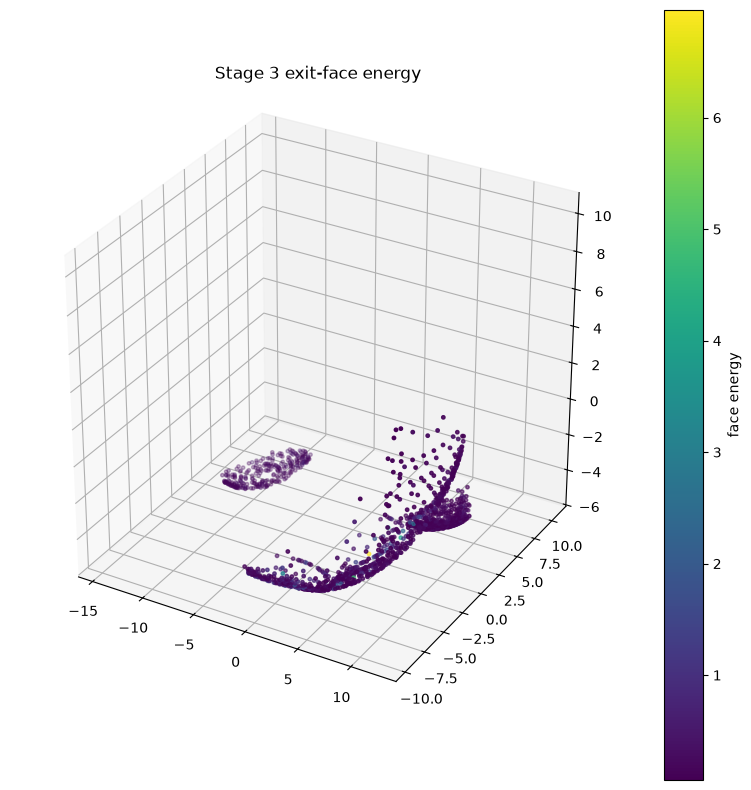

In [5]:
plot_face_state_on_mesh_3d(
    mesh,
    exit_state,
    title="Stage 3 exit-face energy",
    show_mesh_hull=True,
)


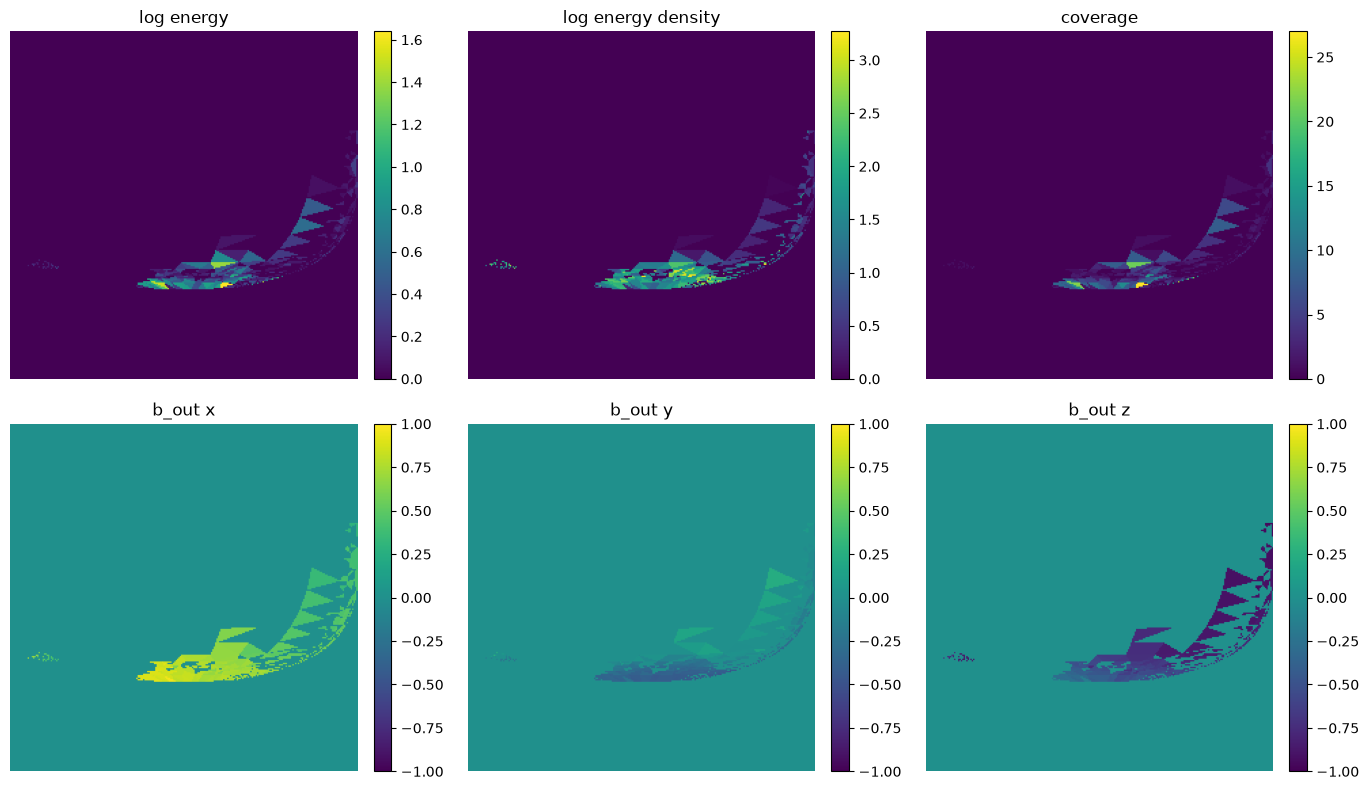

In [6]:
camera = PinholeCameraConfig(
    camera_position=(0.0, -40.0, 0.0),
    look_at=(0.0, 0.0, 0.0),
    up=(0.0, 0.0, 1.0),
    fov_deg=35.0,
    resolution=256,
)
camera_rays = make_pinhole_rays(camera)
_valid, _depth, cam_hit_faces = first_visible_hits(mesh, camera_rays)

images = sample_face_state_camera_images(
    exit_state,
    cam_hit_faces,
    camera_rays.sample_shape,
    face_areas=mesh.area_faces,
)
plot_face_state_camera_panel(
    images,
    show_raw_energy=False,
    show_energy_density=True,
)
